![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Model-Specific Interpretation with Forest-Guided Clustering (FGC)

In this Notebook, we will demonstrate how to use the Forest-Guided Clustering (FGC) method for Random Forest models and interpret its results.

--------


## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/2026-HIDA-Spring/xai-for-random-forest/Gen-4-Tutorial_FGC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# Mount drive folder to dbe abale to download repo
from google.colab import drive
drive.mount('/content/drive')

# Switch to correct folder'
%cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
%rm -r XAI-Tutorials
!git clone --branch 2026-HIDA-Spring https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
%cd XAI-Tutorials
!pip install -r requirements_xai-for-random-forest.txt
%cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [1]:
import pickle

import numpy as np
import pandas as pd

from fgclustering import (
    DistanceRandomForestLCA,
    ClusteringKMedoids,
    forest_guided_clustering, 
    forest_guided_feature_importance, 
    plot_forest_guided_clustering,
    plot_forest_guided_feature_importance, 
    plot_forest_guided_decision_paths
)

import warnings
warnings.filterwarnings('ignore')

We fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [2]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

--------

## Data and Model Loading: The California Housing Dataset

In this notebook, we will work with the **California Housing dataset**, containing 20,640 median house values for California districts (expressed in $100,000), which are described by eight numeric features. Each row in the dataset represents a block of houses, not a single household. The data pertains to the house prices found in a given California district and some summary statistics based on the 1990 census data. Our goal is to **predict the price** of house blocks and find the most predictive features.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/dataset_california_housing.jpg?raw=true" width="900" /></center>

<font size=1> Source: [Link](https://www.kaggle.com/datasets/harrywang/housing)

In the notebook [*Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb*](./Gen-0-Tutorial_RandomForest_Model_Housing_Wine_Penguins.ipynb), we explain how to do the exploratory data analysis, preprocess the data and train a Random Forest model with the given data. The focus of this notebook is the interpretation of the previously trained model.

In [3]:
# Load and unpack the data
with open('../models/model_rf_housing.pickle', 'rb') as handle:
    data_and_model = pickle.load(handle)

X_train = data_and_model[0]
X_test = data_and_model[1]
y_train = data_and_model[2]
y_test = data_and_model[3]
model_housing = data_and_model[4]

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(model_housing.score(X_train, y_train),2)} R^2.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(model_housing.score(X_test, y_test),2)} R^2.')

Model Performance on training data: 0.84 R^2.
Model Performance on test data: 0.72 R^2.


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

*Note: The $R^2$ is the coefficient of determination, and the closer this value is to 1, the better our model explains the data. A constant model that always predicts the average target value disregarding the input features would get an $R^2$ score of 0. However, the $R^2$ score can also be negative because the model can be arbitrarily worse.*

## Now, what does my Random Forest model actually think is important in the data?

### Forest-Guided Clustering

**We prepared a small [Introduction to FGC](https://xai-tutorials.readthedocs.io/en/latest/_model_specific_xai/fgc.html) for you, to help you understand how this method works.**

<font color='green'>

#### Question 1: How is the similarity between instances calculated?

<font color='grey'>

#### Your Answer: 

<font color='green'>

#### Question 2: How do we choose the number of cluster k for the k-medoids clustering?

<font color='grey'>

#### Your Answer: 


Now let's use FGC to get some insights into the Random Forest Regression model we loaded above. FGC can help us to gain some insights into the decision-making process of the Random Forest model. We use the preprocessed dataset and trained Random Forest model as input for a FgClustering object. We have to indicate which column of the dataset contains the target values in the `target_column` parameter. 

*Note: this method is a **global** method meaning it only provides explanations for the full dataset, but not for individual examples.*

### Optimizing the Number of Clusters for FGC

FGC is based on the k-medoids clustering algorithm, which typically requires the number of clusters to be specified in advance. To address this, FGC can automatically optimize the number of clusters using a scoring function that balances predictive fidelity against model complexity. The argument `k` can therefore either be set to a fixed number of clusters or to a range of candidate values for optimization. In the latter case, FGC evaluates the score for each candidate *k* and selects the configuration that provides the best trade-off between simplicity and explanatory quality.

In [4]:
# run FGC 
fgc = forest_guided_clustering(
    k=(2,6),
    estimator=model_housing, 
    X=X_train, 
    y=y_train, 
    clustering_distance_metric=DistanceRandomForestLCA(),
    clustering_strategy=ClusteringKMedoids(method="fasterpam"),
    n_jobs=4, 
)

Using a sample size of 80.00% of the input data for Jaccard Index computation.
Using range k = (2, 6) to optimize k.


Optimizing k: 100%|██████████| 5/5 [04:27<00:00, 53.41s/it]


Optimal number of clusters k = 5

Clustering Evaluation Summary:
 k    Score  Stable  Mean_JI                                                   Cluster_JI
 2 0.871349    True    0.660                                         {1: 0.561, 2: 0.758}
 3 0.470480    True    0.979                                {1: 0.989, 2: 0.979, 3: 0.97}
 4 0.421932    True    0.932                      {1: 0.973, 2: 0.89, 3: 0.913, 4: 0.951}
 5 0.380268    True    0.954           {1: 0.976, 2: 0.955, 3: 0.948, 4: 0.916, 5: 0.974}
 6 0.385511    True    0.959 {1: 0.988, 2: 0.937, 3: 0.949, 4: 0.934, 5: 0.963, 6: 0.983}


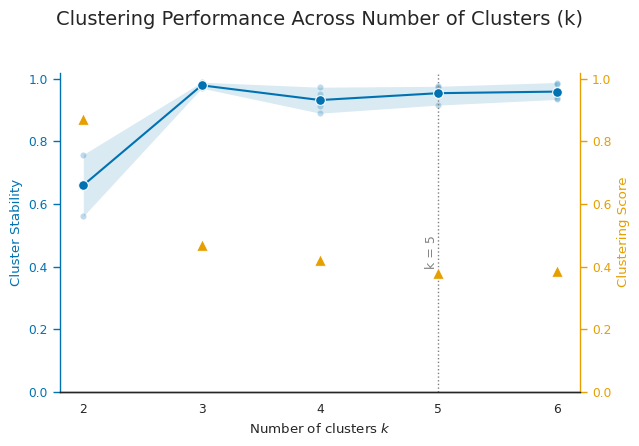

In [5]:
plot_forest_guided_clustering(
    ks=fgc.ks, 
    scores=fgc.scores, 
    mean_ji=fgc.mean_ji, 
    cluster_jis=fgc.cluster_jis, 
    best_k=fgc.best_k, 
)

FGC evaluated cluster solutions ranging from k=2 to k=6 using cluster stability based on the Jaccard Index together with a clustering score that balances model fidelity and complexity. Lower clustering scores indicate better solutions.

All solutions with k>=3 showed high cluster stability, with mean Jaccard Indices above 0.9. The optimal solution was selected at k=5, which achieved the lowest clustering score among the stable solutions while maintaining a high mean Jaccard Index of 0.94. The consistently high cluster-wise Jaccard Indices further indicate that the discovered clusters are robust and reproducible across subsamples of the data.

During model training, the feature values were standardized before fitting the model. While this is beneficial for training, standardized values are often harder to interpret in visualizations. FGC allows us to map the features back to their original scale, making the results easier to understand. To achieve this, we use the scaler object saved during training to inverse-transform the feature values before calculating and visualizing the feature importances.

In [6]:
# get original unscaled feature values
scaler = data_and_model[5]
X_train_unscaled = scaler.inverse_transform(X_train)
X_train_unscaled = pd.DataFrame(X_train_unscaled, columns = X_train.columns)

# re-calculate the cluster-wise statistics for the unscaled features
feature_importance = forest_guided_feature_importance(
    X=X_train_unscaled, 
    y=y_train, 
    y_pred=model_housing.predict(X_train),
    cluster_labels=fgc.cluster_labels[fgc.best_k],
    feature_importance_distance_metric="wasserstein",
)

100%|██████████| 8/8 [00:00<00:00, 490.38it/s]


FGC provides a couple of ways to visualise the results and help interpret them:

- visualise global and local feature importance: features that show different and concise value distributions across clusters are defined to be globally or locally important
- reveal the decision path of the RF model by visualizing feature patterns per cluster

### Global and Local Feature Importance provided by FGC

Now that we have identified the optimal clustering of data points guided by the Random Forest decision paths, we can analyze which features are most characteristic of the discovered clusters. The `forest_guided_feature_importance()` function computes both global and local feature importance directly from feature distributions, without relying on surrogate models.

For the **local feature importance**, the feature distribution within a specific cluster is compared to the overall feature distribution across the complete dataset. Features whose distributions differ strongly from the global distribution are considered particularly characteristic for that cluster.

The **global feature importance** is obtained by averaging these distribution differences across all clusters. Features that consistently distinguish clusters therefore receive high global importance scores.

To quantify the differences between feature distributions, FGC supports distance-based metrics such as the **Wasserstein distance** and the **Jensen–Shannon distance**. In general, the Wasserstein distance is well suited for mostly continuous features, while the Jensen–Shannon distance is particularly useful for categorical or binary features. Larger distances indicate stronger differences between distributions and therefore higher feature importance.

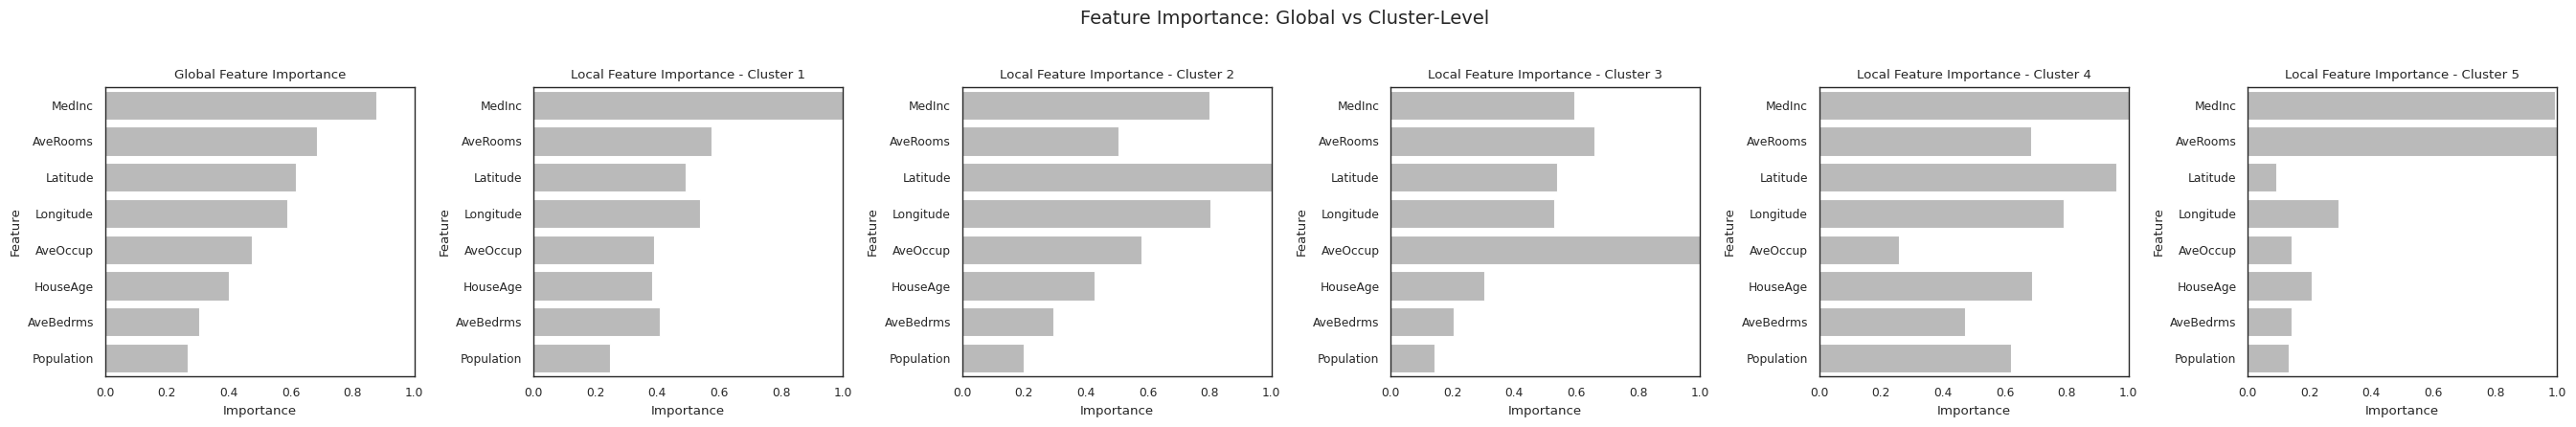

In [7]:
plot_forest_guided_feature_importance(
    feature_importance_local=feature_importance.feature_importance_local,
    feature_importance_global=feature_importance.feature_importance_global,
    reorder=True,
    num_cols=6,
)

The plots above show that while several features are globally important for distinguishing the clusters, the relevance of individual features differs substantially between clusters. Globally, `MedInc`, `AveRooms`, `Latitude`, and `Longitude` are the most important features overall.

At the cluster level, however, different patterns emerge. For example, cluster 3 is strongly characterized by `AveOccup`, while cluster 2 is particularly defined by `Latitude`. Cluster 5 is dominated almost entirely by `MedInc` and `AveRooms`, whereas most other features contribute only weakly to distinguishing this cluster from the overall dataset.

These local feature importance profiles therefore help identify which features are specifically characteristic for individual clusters, providing a more detailed understanding of the decision structure learned by the Random Forest model.

### Visualizing the decision paths of the Random Forest model

Forest-Guided Clustering provides several ways to visualize the decision structure learned by the Random Forest model. These visualizations help us understand how the model partitions the dataset and which features characterize the discovered clusters. The **heatmap** provides a compact overview of feature enrichment or depletion together with the target value distribution across clusters. This helps identify which clusters correspond to which classes or target ranges and can reveal outliers or unusual samples. The **feature distribution plots** show the original, non-standardized feature values within each cluster. They help us inspect how strongly features separate the clusters and how feature values vary within and across clusters. The **dot plot** combines local and global feature importance into a compact summary visualization, highlighting which features are most characteristic for each cluster and how they differ from the overall dataset distribution.

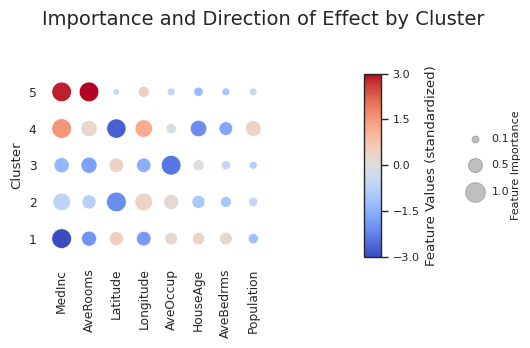

In [8]:
plot_forest_guided_decision_paths(
    data_clustering=feature_importance.data_clustering,
    feature_importance_global=feature_importance.feature_importance_global,
    feature_importance_local=feature_importance.feature_importance_local,
    model_type=fgc.model_type,
    draw_heatmap=False,
    draw_distributions=False,
    draw_dotplot=True,
)

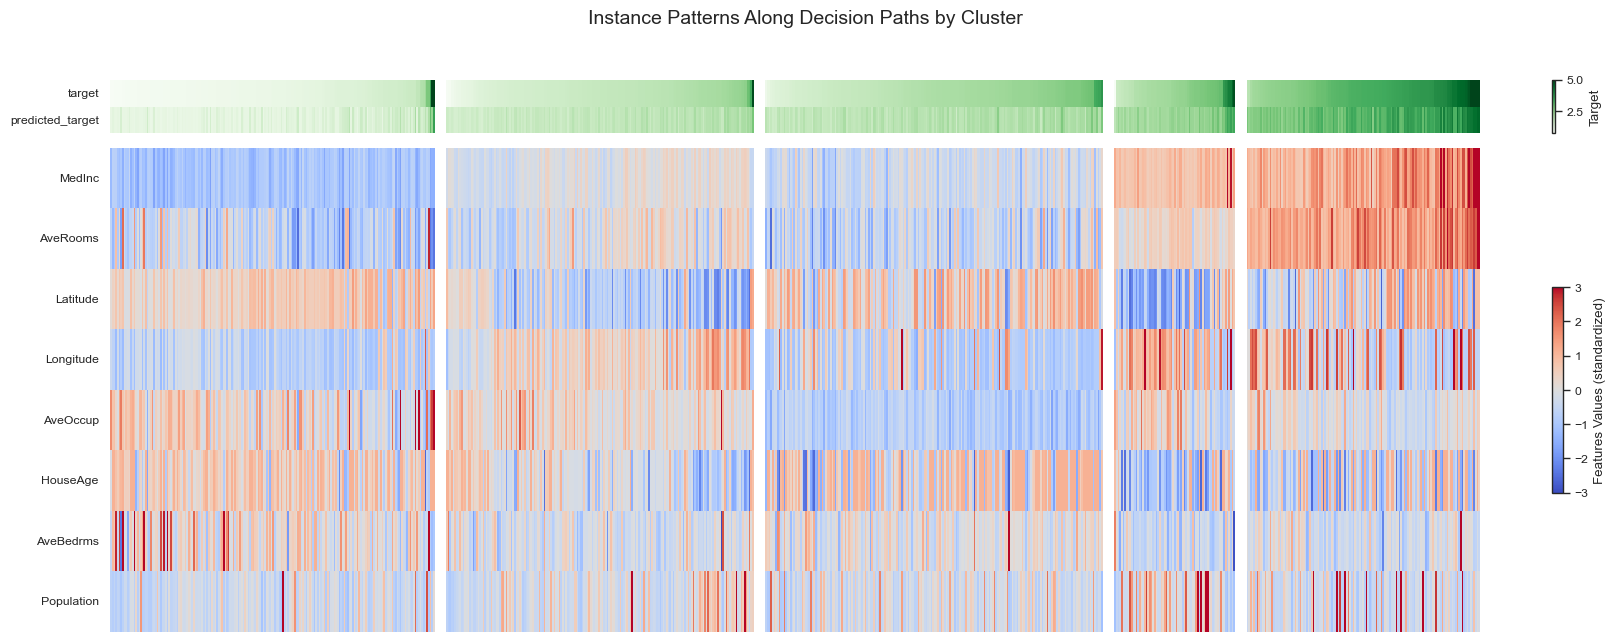

In [9]:
plot_forest_guided_decision_paths(
    data_clustering=feature_importance.data_clustering,
    feature_importance_global=feature_importance.feature_importance_global,
    feature_importance_local=feature_importance.feature_importance_local,
    model_type=fgc.model_type,
    draw_heatmap=True,
    draw_distributions=False,
    draw_dotplot=False,
)

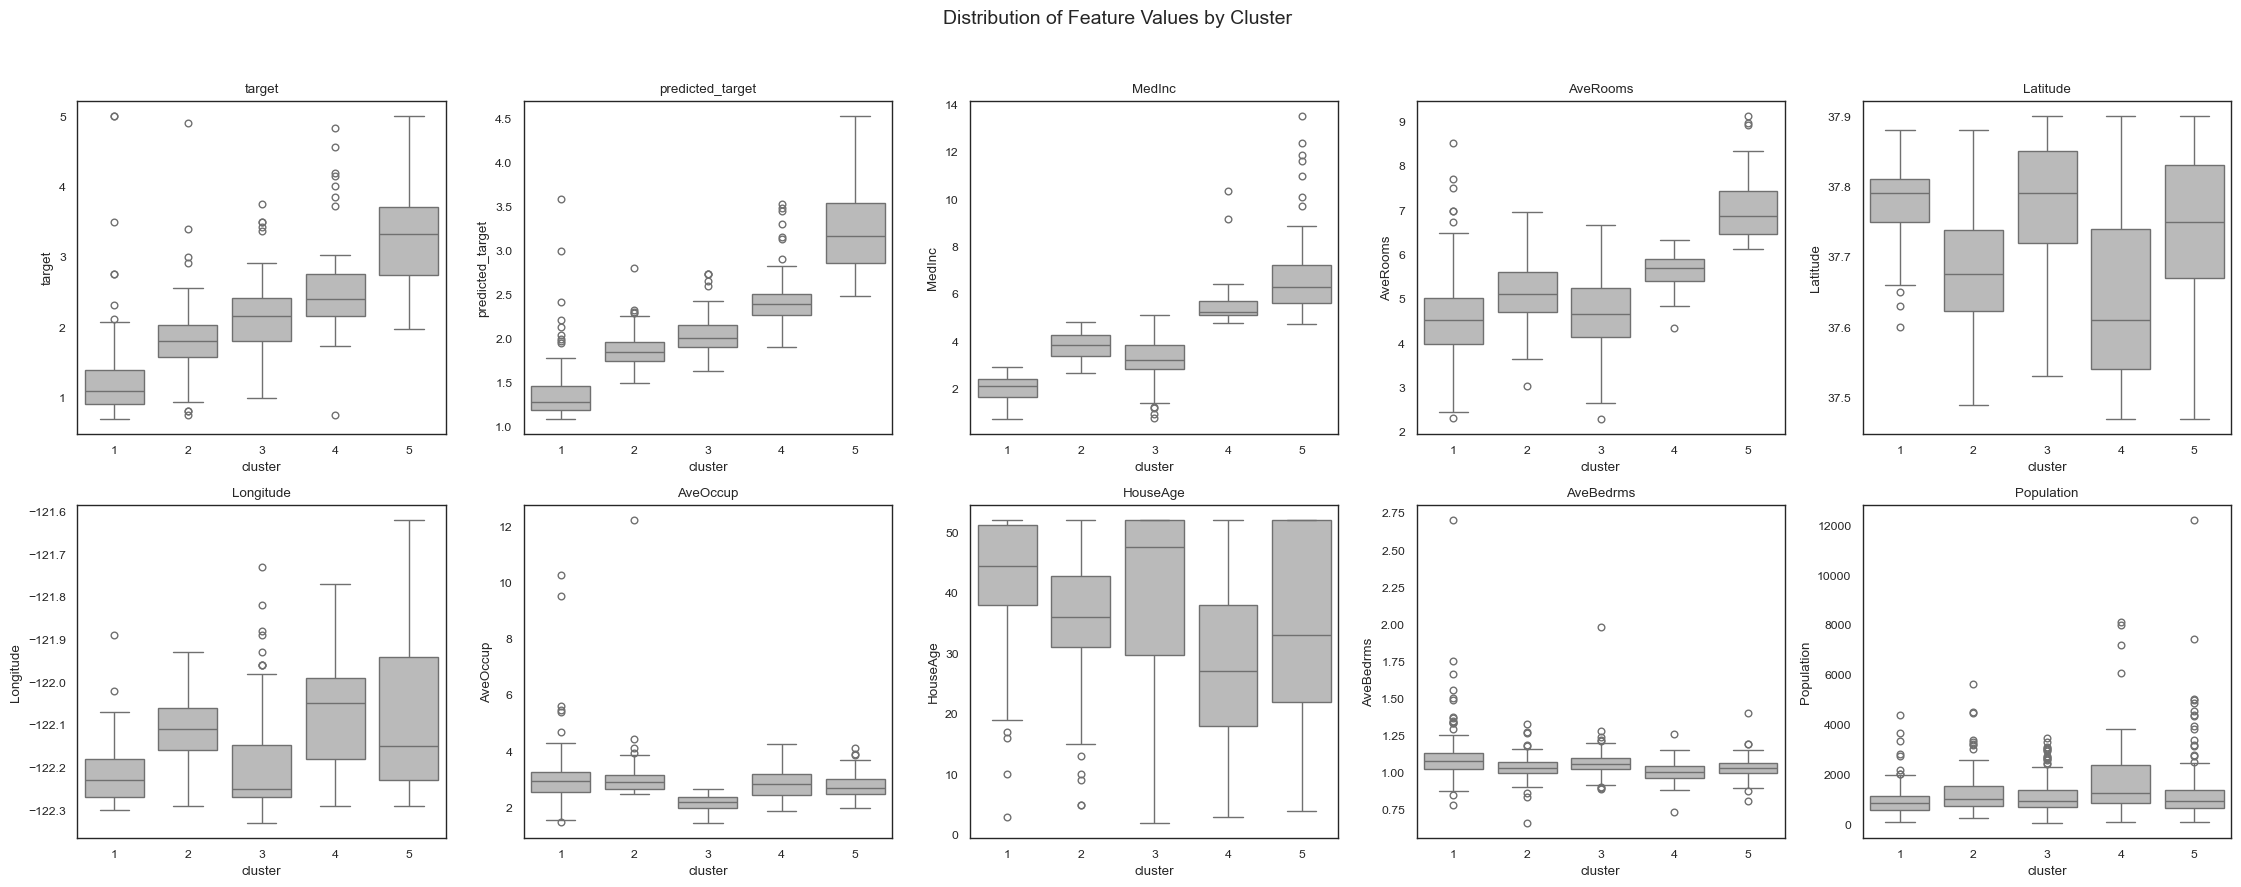

In [10]:
plot_forest_guided_decision_paths(
    data_clustering=feature_importance.data_clustering,
    feature_importance_global=feature_importance.feature_importance_global,
    feature_importance_local=feature_importance.feature_importance_local,
    model_type=fgc.model_type,
    num_cols=5,
    draw_heatmap=False,
    draw_distributions=True,
    draw_dotplot=False,
)

<font color='green'>

#### Question 3: The feature AveRooms has a high feature importance, how is its distribution across clusters?

<font color='grey'>

#### Your Answer: 

<font color='green'>

#### Question 4: Which conclusions can we draw from the decision path plots above?

<font color='grey'>

#### Your Answer: 

